# Operational Analysis Notebook
## DustiniaDelixia Groceria — Final Project MCI 2026
**Persona:** Operational Analyst  
**Tujuan:** Menjawab 5 pertanyaan bisnis operasional untuk Head of Operational  
**Sumber data:** ClickHouse (fact_operational_delivery) atau CSV lokal (fallback)

---
> Notebook ini dijalankan **setelah** DAG Airflow berhasil mengisi ClickHouse.  
> Jika ClickHouse belum tersedia, gunakan mode CSV lokal di cell konfigurasi.


## 0. Setup & Konfigurasi

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
})
sns.set_palette("Set2")


# Pilih Mode Data: 'clickhouse' atau 'csv'
DATA_MODE = 'clickhouse'   # Ganti ke 'csv' jika ClickHouse belum running
DATA_DIR  = './include/data/'  # Path ke folder CSV (fallback)

print(f"Setup selesai. Mode data: {DATA_MODE.upper()}")


Setup selesai. Mode data: CLICKHOUSE


In [17]:
if DATA_MODE == 'clickhouse':
    try:
        from clickhouse_driver import Client
        client = Client(host='clickhouse', port=9000, user='airflow', password='', database='airflow')
        
        query = "SELECT * FROM fact_operational_delivery"
        data, columns = client.execute(query, with_column_types=True)
        col_names = [c[0] for c in columns]
        df = pd.DataFrame(data, columns=col_names)
        print(f"✓ Data loaded dari ClickHouse: {len(df):,} baris")
        
    except Exception as e:
        print(f"✗ ClickHouse failed: {str(e)}")
        print("  Fallback ke mode CSV...\n")
        DATA_MODE = 'csv'

if DATA_MODE == 'csv':
    # Mode CSV: bangun ulang dari raw files
    orders      = pd.read_csv(DATA_DIR + 'orders.csv')
    items       = pd.read_csv(DATA_DIR + 'order_items.csv')
    customers   = pd.read_csv(DATA_DIR + 'customers.csv')
    sellers     = pd.read_csv(DATA_DIR + 'sellers.csv')
    geolocation = pd.read_csv(DATA_DIR + 'geolocation.csv')
    products    = pd.read_csv(DATA_DIR + 'products.csv')
    reviews     = pd.read_csv(DATA_DIR + 'order_reviews.csv')

    # --- Cleaning Orders ---
    time_cols = ['order_purchase_timestamp','order_approved_at',
                 'order_delivered_carrier_date','order_delivered_customer_date',
                 'order_estimated_delivery_date']
    for col in time_cols:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')
    orders = orders[orders['order_status'] == 'delivered'].copy()
    orders.dropna(subset=['order_approved_at','order_delivered_customer_date',
                          'order_delivered_carrier_date'], inplace=True)

    # Feature engineering
    orders['approval_time_days']      = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
    orders['seller_processing_days']  = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / 86400
    orders['carrier_transit_days']    = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / 86400
    orders['actual_delivery_days']    = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
    orders['delay_days']              = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.total_seconds() / 86400
    orders['is_delayed']              = (orders['delay_days'] > 0).astype(int)
    for col in ['approval_time_days','seller_processing_days','carrier_transit_days']:
        orders[col] = orders[col].clip(lower=0)

    # --- Cleaning Geolocation ---
    geo_clean = geolocation.groupby('geolocation_zip_code_prefix').agg(
        lat=('geolocation_lat','mean'), lng=('geolocation_lng','mean'),
        city=('geolocation_city','first'), state=('geolocation_state','first')
    ).reset_index()
    geo_clean['geolocation_zip_code_prefix'] = geo_clean['geolocation_zip_code_prefix'].astype(str)

    # --- Cleaning lainnya ---
    products['product_category_name'] = products['product_category_name'].fillna('unknown')
    products.dropna(subset=['product_weight_g','product_length_cm','product_height_cm','product_width_cm'], inplace=True)
    customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)
    sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str)
    items['price'] = pd.to_numeric(items['price'], errors='coerce')
    items['freight_value'] = pd.to_numeric(items['freight_value'], errors='coerce')
    reviews.drop(columns=['review_comment_title','review_comment_message'], inplace=True, errors='ignore')
    reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce')

    # --- Build fact table via JOIN ---
    items_first = items.drop_duplicates('order_id')
    df = (orders
          .merge(items_first[['order_id','product_id','seller_id','price','freight_value']], on='order_id', how='left')
          .merge(products[['product_id','product_category_name','product_weight_g']], on='product_id', how='left')
          .merge(sellers[['seller_id','seller_city','seller_state','seller_zip_code_prefix']], on='seller_id', how='left')
          .merge(customers[['customer_id','customer_city','customer_state','customer_zip_code_prefix']], on='customer_id', how='left')
          .merge(geo_clean[['geolocation_zip_code_prefix','lat','lng']].rename(columns={'lat':'customer_lat','lng':'customer_lng','geolocation_zip_code_prefix':'customer_zip_code_prefix'}), on='customer_zip_code_prefix', how='left')
          .merge(reviews[['order_id','review_score']], on='order_id', how='left')
    )
    print(f"✓ Fact table dibangun dari CSV: {len(df):,} baris")

print(f"\n✓ Kolom tersedia: {list(df.columns)}")


✗ ClickHouse failed: No module named 'clickhouse_driver'
  Fallback ke mode CSV...

✓ Fact table dibangun dari CSV: 96,984 baris

✓ Kolom tersedia: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'approval_time_days', 'seller_processing_days', 'carrier_transit_days', 'actual_delivery_days', 'delay_days', 'is_delayed', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name', 'product_weight_g', 'seller_city', 'seller_state', 'seller_zip_code_prefix', 'customer_city', 'customer_state', 'customer_zip_code_prefix', 'customer_lat', 'customer_lng', 'review_score']


---
## 1. On-Time Delivery Rate Keseluruhan
> **Pertanyaan:** Berapa persen pesanan yang berhasil dikirim tepat waktu?

  Total Pesanan Delivered   : 96,984
  Tepat Waktu              : 89,120  (91.89%)
  Terlambat                : 7,864  (8.11%)

  Median keterlambatan : 5.8 hari
  Keterlambatan max    : 189 hari


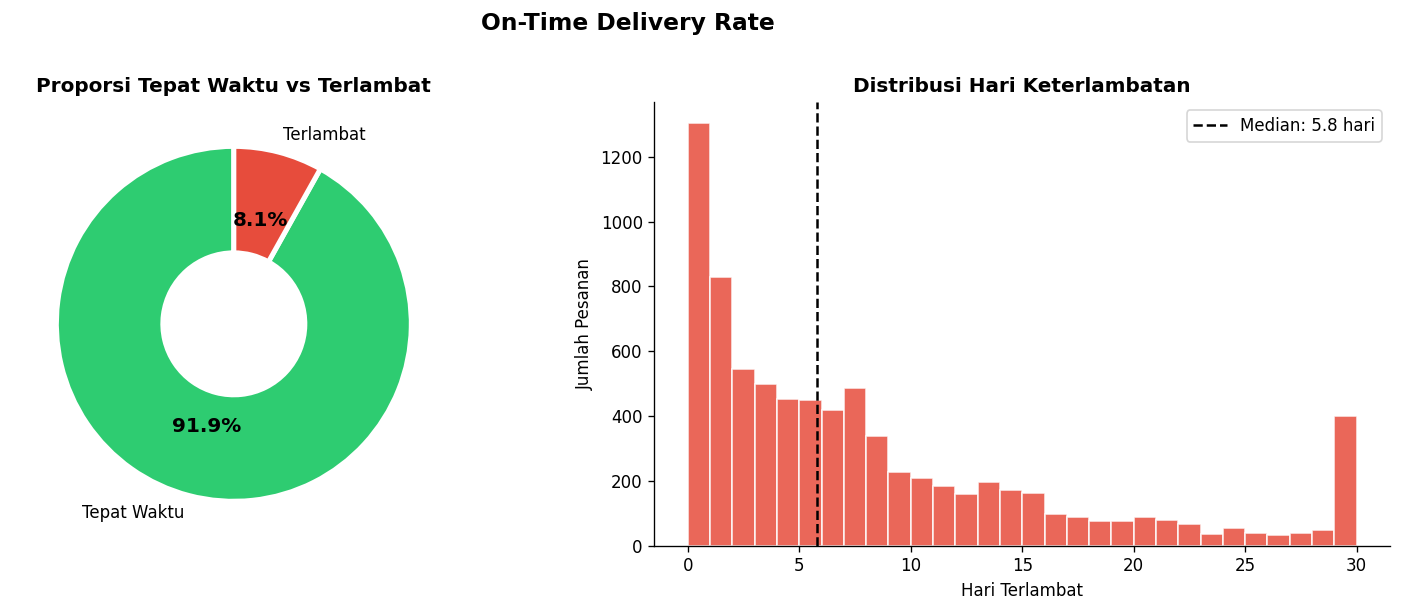

In [18]:
total    = len(df)
on_time  = (df['is_delayed'] == 0).sum()
delayed  = (df['is_delayed'] == 1).sum()
otr      = on_time / total * 100
dr       = delayed / total * 100

print("=" * 55)
print(f"  Total Pesanan Delivered   : {total:,}")
print(f"  Tepat Waktu              : {on_time:,}  ({otr:.2f}%)")
print(f"  Terlambat                : {delayed:,}  ({dr:.2f}%)")
print("=" * 55)

median_delay = df[df['is_delayed']==1]['delay_days'].median()
max_delay    = df[df['is_delayed']==1]['delay_days'].max()
print(f"\n  Median keterlambatan : {median_delay:.1f} hari")
print(f"  Keterlambatan max    : {max_delay:.0f} hari")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('On-Time Delivery Rate', fontsize=14, fontweight='bold', y=1.01)

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    [on_time, delayed],
    labels=[f'Tepat Waktu', f'Terlambat'],
    autopct='%1.1f%%', startangle=90,
    colors=['#2ecc71','#e74c3c'],
    wedgeprops={'edgecolor':'white','linewidth':3,'width':0.6}
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Proporsi Tepat Waktu vs Terlambat')

# Histogram delay days (hanya yang terlambat)
delayed_df = df[df['is_delayed']==1]['delay_days'].clip(0, 30)
axes[1].hist(delayed_df, bins=30, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].axvline(median_delay, color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {median_delay:.1f} hari')
axes[1].set_title('Distribusi Hari Keterlambatan')
axes[1].set_xlabel('Hari Terlambat')
axes[1].set_ylabel('Jumlah Pesanan')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 2. Bottleneck Stage Pipeline
> **Pertanyaan:** Tahap mana yang paling lama — approval, seller processing, atau carrier transit?

--- Statistik SLA per Stage (Hari) ---


,Approval\n(Purchase→Approved),Seller Processing\n(Approved→Carrier),Carrier Transit\n(Carrier→Customer)
count,96984.00,96984.00,96984.00
mean,0.43,2.82,9.33
std,0.86,3.47,8.76
min,0.00,0.00,0.00
25%,0.01,0.88,4.10
50%,0.01,1.82,7.10
75%,0.61,3.58,12.03
max,30.89,125.76,205.19



→ BOTTLENECK UTAMA: Carrier Transit (Carrier→Customer) (9.33 hari rata-rata)


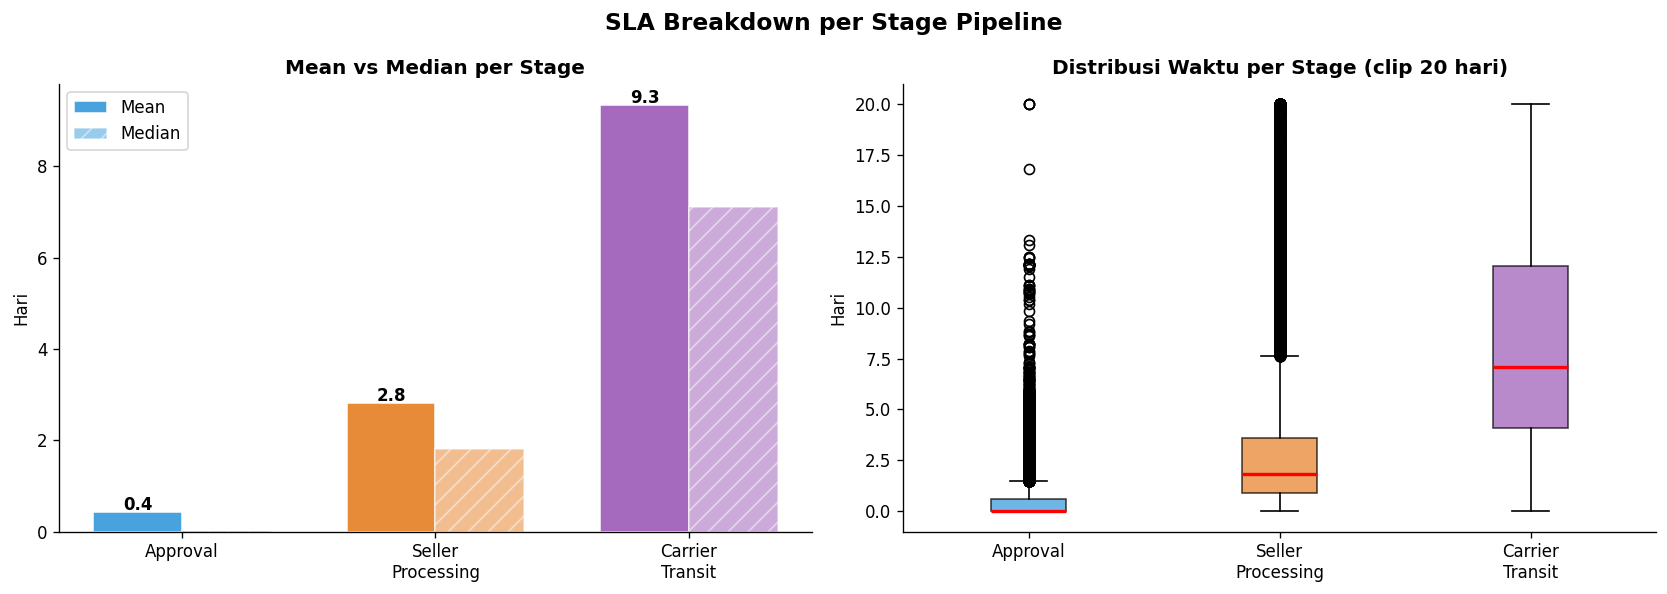

In [19]:
stages = {
    'Approval\n(Purchase→Approved)': 'approval_time_days',
    'Seller Processing\n(Approved→Carrier)': 'seller_processing_days',
    'Carrier Transit\n(Carrier→Customer)': 'carrier_transit_days',
}
means   = {k: df[v].mean() for k, v in stages.items()}
medians = {k: df[v].median() for k, v in stages.items()}

print("--- Statistik SLA per Stage (Hari) ---")
stage_df = df[list(stages.values())].describe().round(2)
stage_df.columns = list(stages.keys())
display(stage_df)

bottleneck = max(means, key=means.get)
print(f"\n→ BOTTLENECK UTAMA: {bottleneck.replace(chr(10),' ')} ({means[bottleneck]:.2f} hari rata-rata)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SLA Breakdown per Stage Pipeline', fontsize=14, fontweight='bold')

colors = ['#3498db','#e67e22','#9b59b6']
x = range(len(stages))
short_labels = ['Approval','Seller\nProcessing','Carrier\nTransit']

# Bar: mean vs median
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x], list(means.values()), width, label='Mean', color=colors, alpha=0.9, edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x], list(medians.values()), width, label='Median', color=colors, alpha=0.5, edgecolor='white', hatch='//')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(short_labels)
axes[0].set_ylabel('Hari'); axes[0].set_title('Mean vs Median per Stage')
axes[0].legend()

# Boxplot
bp_data = [df[v].clip(0, 20) for v in stages.values()]
bp = axes[1].boxplot(bp_data, labels=short_labels, patch_artist=True,
                      medianprops={'color':'red','linewidth':2})
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('Distribusi Waktu per Stage (clip 20 hari)')
axes[1].set_ylabel('Hari')

plt.tight_layout()
plt.show()


---
## 3. Top Seller dengan Delay Rate Tertinggi
> **Pertanyaan:** Seller mana yang paling sering menyebabkan keterlambatan?

Jumlah seller aktif (≥10 order): 1,229
Rata-rata delay rate seller    : 8.04%

--- Top 15 Seller dengan Delay Rate Tertinggi ---


,seller_city,seller_state,total_orders,delayed_orders,delay_rate_pct,avg_processing_days,avg_review_score
seller_id,,,,,,,
b1b3948701c5c72445495bd161b83a4c,sao paulo,SP,14,9,64.29,15.00,1.93
26e2c91ef821e1ff8985f408788fe35b,ibitinga,SP,12,5,41.67,2.52,3.00
13fa2a6c6b9d0f43cb588d7c82117a12,sao paulo,SP,10,4,40.00,4.38,4.20
f76a3b1349b6df1ee875d1f3fa4340f0,sao paulo,SP,23,9,39.13,8.42,3.39
821fb029fc6e495ca4f08a35d51e53a5,sao paulo,SP,24,9,37.50,1.65,3.48
cb41bfbcbda0aea354a834ab222f9a59,sao paulo,SP,11,4,36.36,7.15,3.27
d9e7e7778b32987280a6f2cb9a39c57d,sao paulo,SP,11,4,36.36,3.75,3.55
02dcd3e8e25bee036e32512bcf175493,contagem,MG,14,5,35.71,3.22,3.86
02d35243ea2e497335cd0f076b45675d,natal,RN,14,5,35.71,9.84,2.64


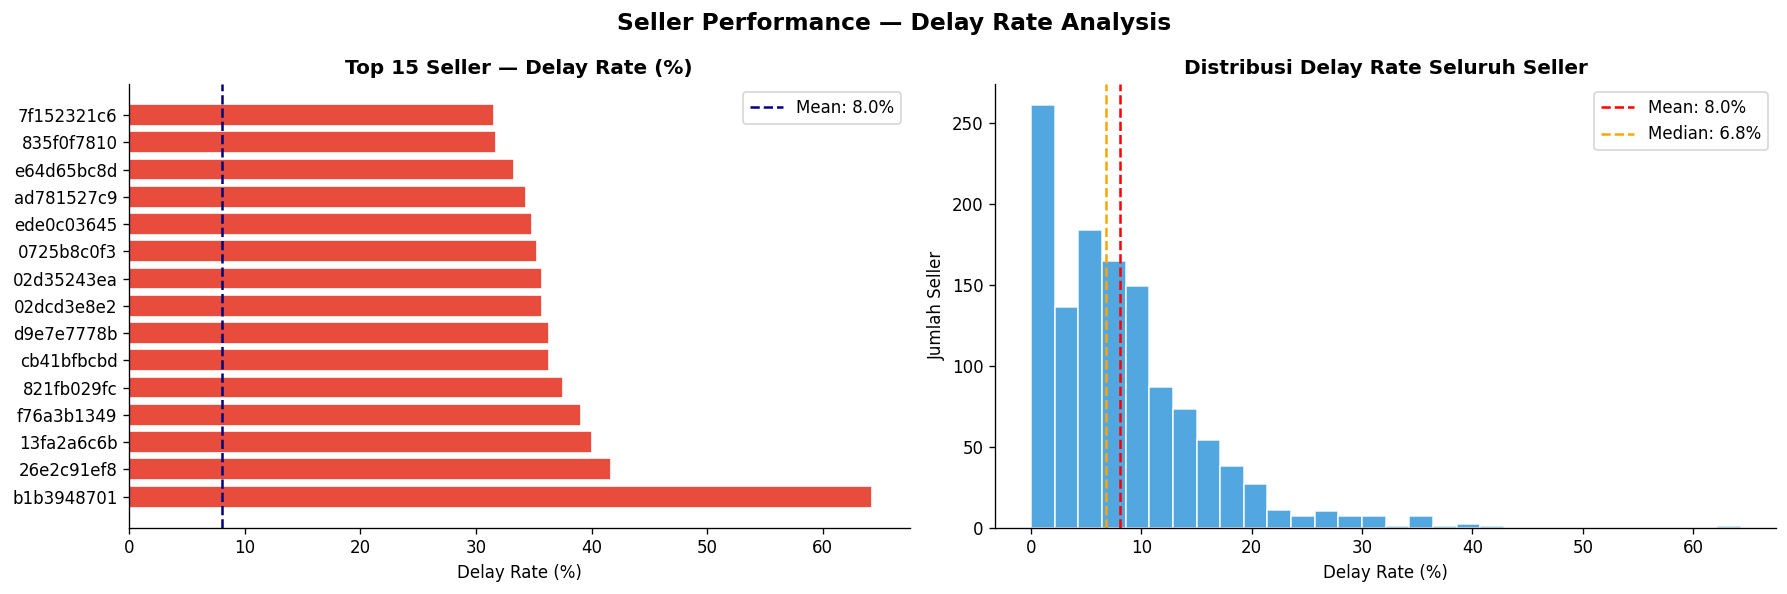


Seller dengan delay rate ≥ 15.3% (mean + 1 std): 170 seller


In [20]:
seller_perf = (
    df.groupby('seller_id')
    .agg(
        total_orders         =('order_id','count'),
        delayed_orders       =('is_delayed','sum'),
        avg_processing_days  =('seller_processing_days','mean'),
        avg_delay_days       =('delay_days','mean'),
        avg_review_score     =('review_score','mean'),
        seller_state         =('seller_state','first'),
        seller_city          =('seller_city','first'),
    )
    .query('total_orders >= 10')
    .assign(delay_rate_pct=lambda x: x['delayed_orders'] / x['total_orders'] * 100)
    .sort_values('delay_rate_pct', ascending=False)
    .round(2)
)

print(f"Jumlah seller aktif (≥10 order): {len(seller_perf):,}")
print(f"Rata-rata delay rate seller    : {seller_perf['delay_rate_pct'].mean():.2f}%")
print(f"\n--- Top 15 Seller dengan Delay Rate Tertinggi ---")
display(seller_perf.head(15)[['seller_city','seller_state','total_orders','delayed_orders','delay_rate_pct','avg_processing_days','avg_review_score']])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Seller Performance — Delay Rate Analysis', fontsize=14, fontweight='bold')

top15 = seller_perf.head(15).copy()
top15['label'] = top15.index.str[:10]
mean_dr = seller_perf['delay_rate_pct'].mean()

colors_bar = ['#e74c3c' if v > mean_dr else '#95a5a6' for v in top15['delay_rate_pct']]
axes[0].barh(top15['label'], top15['delay_rate_pct'], color=colors_bar, edgecolor='white')
axes[0].axvline(mean_dr, color='navy', linestyle='--', linewidth=1.5, label=f'Mean: {mean_dr:.1f}%')
axes[0].set_title('Top 15 Seller — Delay Rate (%)')
axes[0].set_xlabel('Delay Rate (%)')
axes[0].legend()

axes[1].hist(seller_perf['delay_rate_pct'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(mean_dr, color='red', linestyle='--', label=f'Mean: {mean_dr:.1f}%')
axes[1].axvline(seller_perf['delay_rate_pct'].median(), color='orange', linestyle='--',
                label=f"Median: {seller_perf['delay_rate_pct'].median():.1f}%")
axes[1].set_title('Distribusi Delay Rate Seluruh Seller')
axes[1].set_xlabel('Delay Rate (%)'); axes[1].set_ylabel('Jumlah Seller')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identifikasi seller bermasalah
threshold = mean_dr + seller_perf['delay_rate_pct'].std()
problematic = seller_perf[seller_perf['delay_rate_pct'] >= threshold]
print(f"\nSeller dengan delay rate ≥ {threshold:.1f}% (mean + 1 std): {len(problematic):,} seller")


---
## 4. Delay Rate per Wilayah Customer
> **Pertanyaan:** Wilayah mana yang memiliki delay rate dan delivery time tertinggi?

--- Delay Rate & Delivery Performance per Customer State ---


,total_orders,delayed_orders,avg_delivery_days,avg_carrier_transit,avg_seller_proc,avg_review_score,delay_rate_pct
customer_state,,,,,,,
AL,401,96,24.54,21.07,2.98,3.84,23.94
MA,720,141,21.53,17.94,3.03,3.84,19.58
PI,477,76,19.45,16.28,2.76,4.00,15.93
CE,1281,197,21.27,17.94,2.88,3.94,15.38
SE,335,51,21.52,17.95,3.15,3.91,15.22
BA,3273,461,19.36,16.06,2.82,3.93,14.08
RJ,12418,1674,15.32,12.01,2.93,3.96,13.48
TO,274,35,17.66,14.26,2.87,4.15,12.77
PA,952,117,23.78,20.30,2.99,3.91,12.29


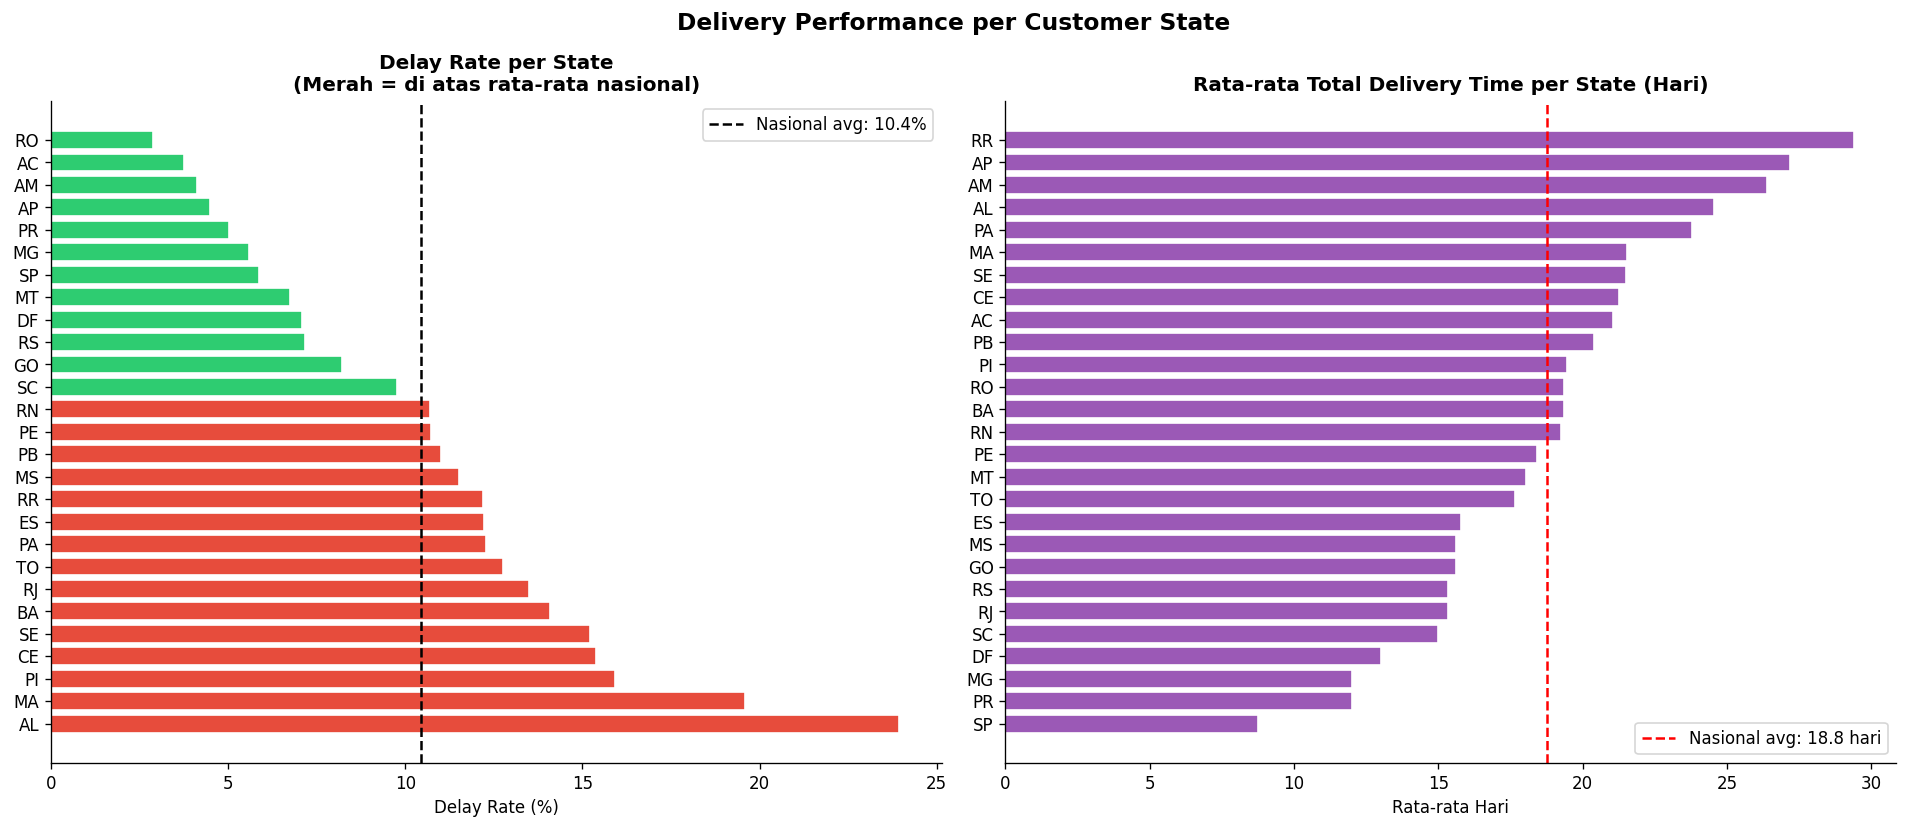


--- Top 5 State Bermasalah ---


,total_orders,delay_rate_pct,avg_delivery_days,avg_carrier_transit,avg_review_score
customer_state,,,,,
AL,401,23.94,24.54,21.07,3.84
MA,720,19.58,21.53,17.94,3.84
PI,477,15.93,19.45,16.28,4.00
CE,1281,15.38,21.27,17.94,3.94
SE,335,15.22,21.52,17.95,3.91


In [21]:
state_perf = (
    df.groupby('customer_state')
    .agg(
        total_orders        =('order_id','count'),
        delayed_orders      =('is_delayed','sum'),
        avg_delivery_days   =('actual_delivery_days','mean'),
        avg_carrier_transit =('carrier_transit_days','mean'),
        avg_seller_proc     =('seller_processing_days','mean'),
        avg_review_score    =('review_score','mean'),
    )
    .assign(delay_rate_pct=lambda x: x['delayed_orders'] / x['total_orders'] * 100)
    .sort_values('delay_rate_pct', ascending=False)
    .round(2)
)

print("--- Delay Rate & Delivery Performance per Customer State ---")
display(state_perf)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Delivery Performance per Customer State', fontsize=14, fontweight='bold')

national_avg_dr = state_perf['delay_rate_pct'].mean()
colors_state = ['#e74c3c' if v > national_avg_dr else '#2ecc71'
                for v in state_perf['delay_rate_pct']]

axes[0].barh(state_perf.index, state_perf['delay_rate_pct'], color=colors_state, edgecolor='white')
axes[0].axvline(national_avg_dr, color='black', linestyle='--', linewidth=1.5,
                label=f'Nasional avg: {national_avg_dr:.1f}%')
axes[0].set_title('Delay Rate per State\n(Merah = di atas rata-rata nasional)')
axes[0].set_xlabel('Delay Rate (%)'); axes[0].legend()

state_perf_sorted_delivery = state_perf.sort_values('avg_delivery_days')
axes[1].barh(state_perf_sorted_delivery.index, state_perf_sorted_delivery['avg_delivery_days'],
             color='#9b59b6', edgecolor='white')
axes[1].axvline(state_perf['avg_delivery_days'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f"Nasional avg: {state_perf['avg_delivery_days'].mean():.1f} hari")
axes[1].set_title('Rata-rata Total Delivery Time per State (Hari)')
axes[1].set_xlabel('Rata-rata Hari'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n--- Top 5 State Bermasalah ---")
display(state_perf.head(5)[['total_orders','delay_rate_pct','avg_delivery_days','avg_carrier_transit','avg_review_score']])


---
## 5. Korelasi Delay vs Review Score
> **Pertanyaan:** Apakah keterlambatan berpengaruh nyata terhadap kepuasan pelanggan?

--- Review Score by Delay Status ---


,mean,median,count,std
Tepat Waktu (0),4.294,5.0,88639,1.148
Terlambat (1),2.566,2.0,7699,1.658



→ Penurunan review score akibat delay: 1.728 poin

--- Review Score per Delay Bucket ---


,mean,count
delay_bucket,,
Tepat Waktu,4.29,88639
Terlambat\n1-3 hari,3.77,2651
Terlambat\n4-7 hari,2.31,1776
Terlambat\n8-14 hari,1.75,1758
Terlambat\n>14 hari,1.71,1514


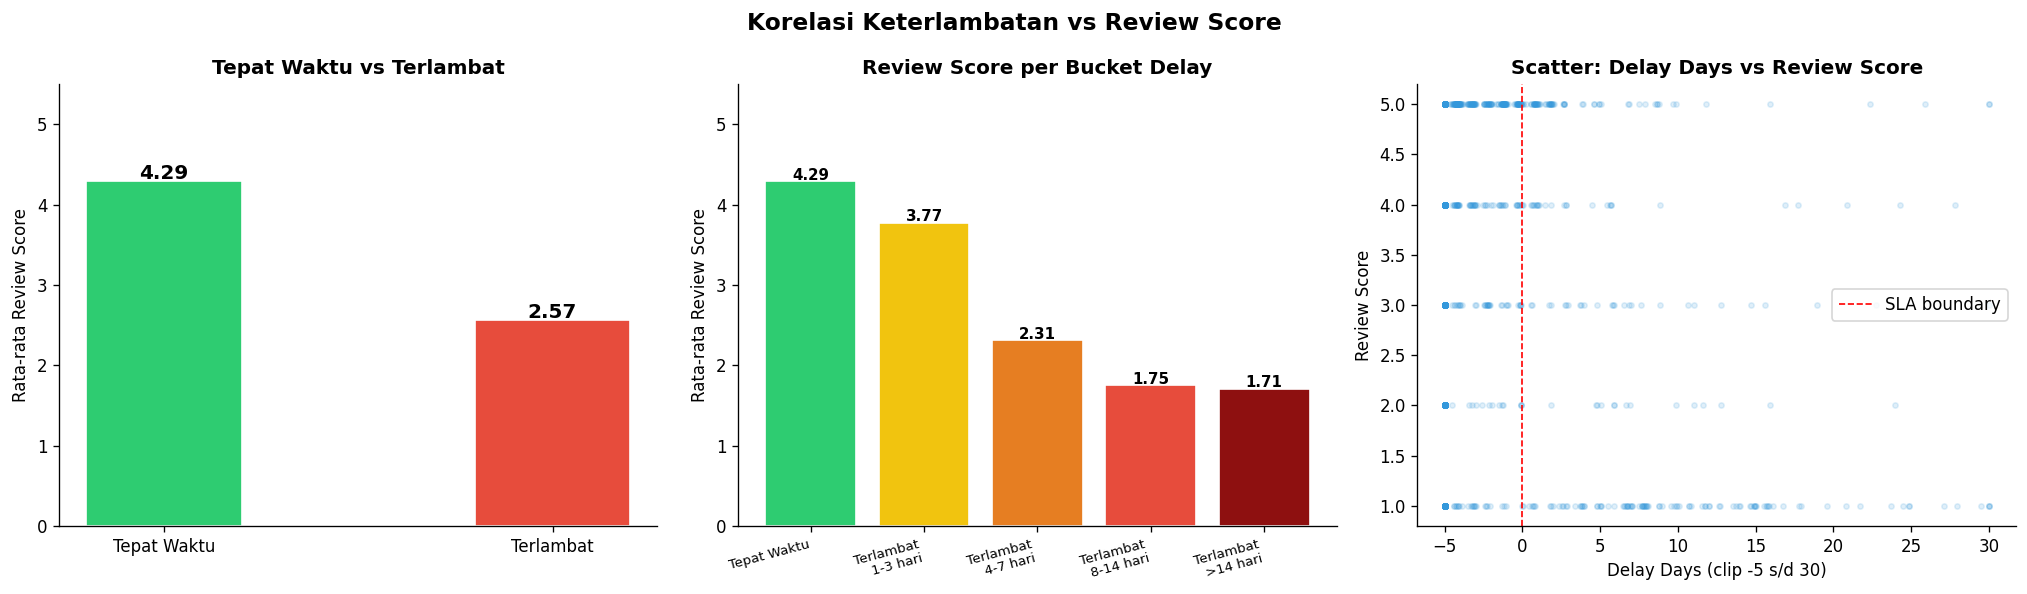

In [22]:
df_rev = df[df['review_score'].notna()].copy()
df_rev['review_score'] = df_rev['review_score'].astype(float)

score_by_delay = df_rev.groupby('is_delayed')['review_score'].agg(['mean','median','count','std']).round(3)
score_by_delay.index = ['Tepat Waktu (0)','Terlambat (1)']
print("--- Review Score by Delay Status ---")
display(score_by_delay)

diff = score_by_delay.loc['Tepat Waktu (0)','mean'] - score_by_delay.loc['Terlambat (1)','mean']
print(f"\n→ Penurunan review score akibat delay: {diff:.3f} poin")

# Bucket delay
df_rev['delay_bucket'] = pd.cut(df_rev['delay_days'],
    bins=[-9999, 0, 3, 7, 14, 9999],
    labels=['Tepat Waktu','Terlambat\n1-3 hari','Terlambat\n4-7 hari',
            'Terlambat\n8-14 hari','Terlambat\n>14 hari'])
score_by_bucket = df_rev.groupby('delay_bucket', observed=True)['review_score'].agg(['mean','count']).round(2)
print("\n--- Review Score per Delay Bucket ---")
display(score_by_bucket)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Korelasi Keterlambatan vs Review Score', fontsize=14, fontweight='bold')

# Bar: on-time vs delayed
c_status = ['#2ecc71','#e74c3c']
bars = axes[0].bar(['Tepat Waktu','Terlambat'],
                   [score_by_delay.loc['Tepat Waktu (0)','mean'],
                    score_by_delay.loc['Terlambat (1)','mean']],
                   color=c_status, edgecolor='white', width=0.4)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 5.5); axes[0].set_ylabel('Rata-rata Review Score')
axes[0].set_title('Tepat Waktu vs Terlambat')

# Bar: by bucket
bucket_means = score_by_bucket['mean']
c_bucket = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e1010']
bars2 = axes[1].bar(range(len(bucket_means)), bucket_means.values,
                    color=c_bucket, edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(bucket_means)))
axes[1].set_xticklabels(bucket_means.index, rotation=15, ha='right', fontsize=8)
axes[1].set_ylim(0, 5.5); axes[1].set_ylabel('Rata-rata Review Score')
axes[1].set_title('Review Score per Bucket Delay')

# Scatter: delay_days vs review_score
sample = df_rev.sample(min(3000, len(df_rev)), random_state=42)
axes[2].scatter(sample['delay_days'].clip(-5, 30), sample['review_score'],
                alpha=0.15, color='#3498db', s=10)
axes[2].set_xlabel('Delay Days (clip -5 s/d 30)')
axes[2].set_ylabel('Review Score')
axes[2].set_title('Scatter: Delay Days vs Review Score')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1, label='SLA boundary')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 6. Ringkasan Eksekutif
> Rekap seluruh temuan untuk presentasi ke Head of Operational

In [23]:
print("=" * 65)
print("  RINGKASAN EKSEKUTIF — OPERATIONAL ANALYST")
print("  DustiniaDelixia Groceria | Final Project MCI 2026")
print("=" * 65)

total     = len(df)
otr       = (df['is_delayed']==0).sum() / total * 100
dr        = (df['is_delayed']==1).sum() / total * 100
stages_m  = {
    'Approval'         : df['approval_time_days'].mean(),
    'Seller Processing': df['seller_processing_days'].mean(),
    'Carrier Transit'  : df['carrier_transit_days'].mean(),
}
bottleneck_stage = max(stages_m, key=stages_m.get)

print(f"\n DELIVERY PERFORMANCE")
print(f"   Total pesanan delivered    : {total:,}")
print(f"   On-Time Delivery Rate      : {otr:.2f}%")
print(f"   Delay Rate                 : {dr:.2f}%")
print(f"\n SLA BREAKDOWN (rata-rata hari)")
for s, v in stages_m.items():
    flag = ' ← BOTTLENECK' if s == bottleneck_stage else ''
    print(f"   {s:<22}: {v:.2f} hari{flag}")
print(f"\n SELLER INSIGHT")
print(f"   Seller aktif (≥10 order)  : {len(seller_perf):,}")
print(f"   Rata-rata delay rate       : {seller_perf['delay_rate_pct'].mean():.2f}%")
print(f"   Seller delay rate >50%     : {(seller_perf['delay_rate_pct']>50).sum():,}")
print(f"\n REGIONAL INSIGHT")
worst_state = state_perf.index[0]
print(f"   State dengan delay tertinggi : {worst_state} ({state_perf.loc[worst_state,'delay_rate_pct']:.1f}%)")
print(f"   State dengan delivery terlama: {state_perf['avg_delivery_days'].idxmax()} ({state_perf['avg_delivery_days'].max():.1f} hari)")
print(f"\n CUSTOMER SATISFACTION")
avg_score_ontime  = df_rev[df_rev['is_delayed']==0]['review_score'].mean()
avg_score_delayed = df_rev[df_rev['is_delayed']==1]['review_score'].mean()
print(f"   Review score tepat waktu  : {avg_score_ontime:.2f} / 5")
print(f"   Review score terlambat    : {avg_score_delayed:.2f} / 5")
print(f"   Dampak delay ke score     : -{(avg_score_ontime - avg_score_delayed):.2f} poin")
print(f"\n REKOMENDASI AKSI")
print(f"   1. SHORT-TERM  : Notifikasi otomatis ke seller saat mendekati batas processing time")
print(f"   2. MID-TERM    : Negosiasi ulang SLA kurir di state {worst_state} dan sekitarnya")
print(f"   3. LONG-TERM   : Pertimbangkan fulfillment center di region dengan volume tinggi & delay tinggi")
print("=" * 65)


  RINGKASAN EKSEKUTIF — OPERATIONAL ANALYST
  DustiniaDelixia Groceria | Final Project MCI 2026

 DELIVERY PERFORMANCE
   Total pesanan delivered    : 96,984
   On-Time Delivery Rate      : 91.89%
   Delay Rate                 : 8.11%

 SLA BREAKDOWN (rata-rata hari)
   Approval              : 0.43 hari
   Seller Processing     : 2.82 hari
   Carrier Transit       : 9.33 hari ← BOTTLENECK

 SELLER INSIGHT
   Seller aktif (≥10 order)  : 1,229
   Rata-rata delay rate       : 8.04%
   Seller delay rate >50%     : 1

 REGIONAL INSIGHT
   State dengan delay tertinggi : AL (23.9%)
   State dengan delivery terlama: RR (29.4 hari)

 CUSTOMER SATISFACTION
   Review score tepat waktu  : 4.29 / 5
   Review score terlambat    : 2.57 / 5
   Dampak delay ke score     : -1.73 poin

 REKOMENDASI AKSI
   1. SHORT-TERM  : Notifikasi otomatis ke seller saat mendekati batas processing time
   2. MID-TERM    : Negosiasi ulang SLA kurir di state AL dan sekitarnya
   3. LONG-TERM   : Pertimbangkan fulfillmen